In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df.head()

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso


# Pregunta 7: Presencialidad vs No Presencialidad

**Pregunta a responder:**
¿Se produjo una gran vuelta a la presencialidad o los formatos que incluyen la no presencialidad han ganado terreno?

**Contexto:**
- Los datos son de 2021, período de transición post-pandemia COVID-19
- La pandemia comenzó en 2020, forzando la educación online
- 2021 fue año de vuelta gradual a la presencialidad

**Análisis a realizar:**
1. Distribución actual de modalidades de estudio
2. Evolución temporal por año de ingreso
3. Comparación por tipo de institución
4. Análisis por área de conocimiento

In [2]:
# Explorar la variable MODALIDAD
print("Valores únicos de MODALIDAD:")
print(df['MODALIDAD'].value_counts())
print(f"\nTotal de registros: {len(df):,}")
print(f"Valores nulos en MODALIDAD: {df['MODALIDAD'].isna().sum()}")

Valores únicos de MODALIDAD:
MODALIDAD
Presencial        106790
Semipresencial      1745
No Presencial        663
Name: count, dtype: int64

Total de registros: 109,198
Valores nulos en MODALIDAD: 0


## 1. Distribución Global de Modalidades (2021)

In [3]:
# Tabla de frecuencias de modalidad
modalidad_counts = df['MODALIDAD'].value_counts()
modalidad_pct = df['MODALIDAD'].value_counts(normalize=True) * 100

tabla_modalidad = pd.DataFrame({
    'Frecuencia': modalidad_counts,
    'Porcentaje': modalidad_pct.round(2)
})

print("="*70)
print("DISTRIBUCIÓN DE MODALIDADES EN 2021")
print("="*70)
print(tabla_modalidad)

# Calcular presencial vs no presencial
presencial = modalidad_counts.get('Presencial', 0)
total = len(df)
no_presencial = total - presencial

pct_presencial = (presencial / total) * 100
pct_no_presencial = (no_presencial / total) * 100

print("\n" + "="*70)
print("RESUMEN: PRESENCIAL VS NO PRESENCIAL")
print("="*70)
print(f"Presencial: {presencial:,} ({pct_presencial:.2f}%)")
print(f"No Presencial (Online/Semipresencial): {no_presencial:,} ({pct_no_presencial:.2f}%)")

DISTRIBUCIÓN DE MODALIDADES EN 2021
                Frecuencia  Porcentaje
MODALIDAD                             
Presencial          106790       97.79
Semipresencial        1745        1.60
No Presencial          663        0.61

RESUMEN: PRESENCIAL VS NO PRESENCIAL
Presencial: 106,790 (97.79%)
No Presencial (Online/Semipresencial): 2,408 (2.21%)


## 2. Evolución Temporal: Análisis por Año de Ingreso

In [4]:
# Análisis por año de ingreso (últimos 10 años para ver tendencia)
años_recientes = df[df['AÑO INGRESO'] >= 2012].copy()

# Crear tabla cruzada: Año x Modalidad
tabla_año_modalidad = pd.crosstab(años_recientes['AÑO INGRESO'], 
                                    años_recientes['MODALIDAD'], 
                                    normalize='index') * 100

print("Porcentaje de estudiantes por modalidad según año de ingreso (2012-2021):")
print("="*90)
print(tabla_año_modalidad.round(2))

# Identificar años clave
print("\n" + "="*90)
print("AÑOS CLAVE:")
print("="*90)
print("2019: Pre-pandemia")
print("2020: Inicio pandemia COVID-19 (educación forzada online)")
print("2021: Transición post-pandemia (los datos que estamos analizando)")

Porcentaje de estudiantes por modalidad según año de ingreso (2012-2021):
MODALIDAD    No Presencial  Presencial  Semipresencial
AÑO INGRESO                                           
2012                  1.58       98.42            0.00
2013                  0.44       99.56            0.00
2014                  0.27       99.59            0.14
2015                  0.13       99.71            0.16
2016                  0.05       99.78            0.16
2017                  0.07       99.88            0.06
2018                  0.15       99.45            0.39
2019                  0.31       98.44            1.25
2020                  0.41       97.25            2.34
2021                  1.45       95.84            2.71

AÑOS CLAVE:
2019: Pre-pandemia
2020: Inicio pandemia COVID-19 (educación forzada online)
2021: Transición post-pandemia (los datos que estamos analizando)


In [ ]:
# Análisis específico de años clave
años_clave = [2019, 2020, 2021]

print("COMPARACIÓN AÑOS CLAVE: 2019 (pre-pandemia) vs 2020 (pandemia) vs 2021 (transición)")
print("="*90)

for año in años_clave:
    df_año = df[df['AÑO INGRESO'] == año]
    total_año = len(df_año)
    
    print(f"\n{año}:")
    print("-" * 90)
    print(f"Total estudiantes: {total_año:,}")
    
    modalidad_año = df_año['MODALIDAD'].value_counts(normalize=True) * 100
    for mod, pct in modalidad_año.items():
        print(f"  {mod}: {pct:.2f}%")

# Calcular cambios
if len(años_clave) >= 2:
    print("\n" + "="*90)
    print("ANÁLISIS DE CAMBIOS:")
    print("="*90)
    
    # Comparar presencialidad entre años
    for i, año in enumerate(años_clave[:-1]):
        año_siguiente = años_clave[i+1]
        
        pct_pres_año1 = tabla_año_modalidad.loc[año, 'Presencial'] if año in tabla_año_modalidad.index and 'Presencial' in tabla_año_modalidad.columns else 0
        pct_pres_año2 = tabla_año_modalidad.loc[año_siguiente, 'Presencial'] if año_siguiente in tabla_año_modalidad.index and 'Presencial' in tabla_año_modalidad.columns else 0
        
        cambio = pct_pres_año2 - pct_pres_año1
        
        print(f"\nCambio {año} → {año_siguiente}:")
        print(f"  Presencial: {pct_pres_año1:.2f}% → {pct_pres_año2:.2f}% (cambio: {cambio:+.2f} pp)")
        
        if cambio > 5:
            print("  → ✓ AUMENTO SIGNIFICATIVO de presencialidad")
        elif cambio < -5:
            print("  →  DISMINUCIÓN SIGNIFICATIVA de presencialidad")
        else:
            print("  → Cambio moderado")

COMPARACIÓN AÑOS CLAVE: 2019 (pre-pandemia) vs 2020 (pandemia) vs 2021 (transición)

2019:
------------------------------------------------------------------------------------------
Total estudiantes: 19,817
  Presencial: 98.44%
  Semipresencial: 1.25%
  No Presencial: 0.31%

2020:
------------------------------------------------------------------------------------------
Total estudiantes: 24,660
  Presencial: 97.25%
  Semipresencial: 2.34%
  No Presencial: 0.41%

2021:
------------------------------------------------------------------------------------------
Total estudiantes: 31,211
  Presencial: 95.84%
  Semipresencial: 2.71%
  No Presencial: 1.45%

ANÁLISIS DE CAMBIOS:

Cambio 2019 → 2020:
  Presencial: 98.44% → 97.25% (cambio: -1.19 pp)
  → Cambio moderado

Cambio 2020 → 2021:
  Presencial: 97.25% → 95.84% (cambio: -1.41 pp)
  → Cambio moderado


## 3. Visualización: Evolución Temporal de Modalidades

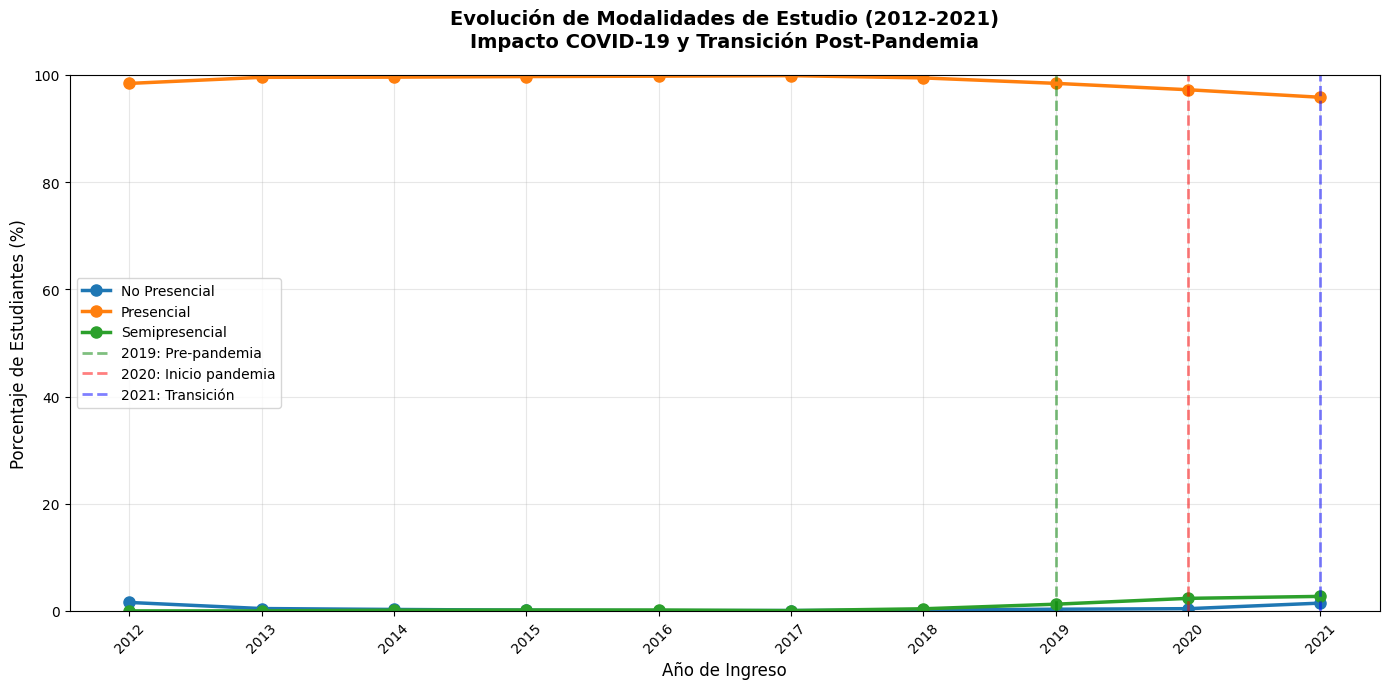

In [6]:
# Gráfico de líneas: evolución de modalidades por año
plt.figure(figsize=(14, 7))

# Preparar datos para el gráfico
for modalidad in tabla_año_modalidad.columns:
    plt.plot(tabla_año_modalidad.index, 
             tabla_año_modalidad[modalidad], 
             marker='o', 
             linewidth=2.5, 
             markersize=8,
             label=modalidad)

# Marcar años clave
plt.axvline(x=2019, color='green', linestyle='--', alpha=0.5, linewidth=2, label='2019: Pre-pandemia')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, linewidth=2, label='2020: Inicio pandemia')
plt.axvline(x=2021, color='blue', linestyle='--', alpha=0.5, linewidth=2, label='2021: Transición')

plt.xlabel('Año de Ingreso', fontsize=12)
plt.ylabel('Porcentaje de Estudiantes (%)', fontsize=12)
plt.title('Evolución de Modalidades de Estudio (2012-2021)\nImpacto COVID-19 y Transición Post-Pandemia', 
          fontsize=14, weight='bold', pad=20)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(tabla_año_modalidad.index, rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 4. Gráfico de Barras Apiladas: Composición por Año

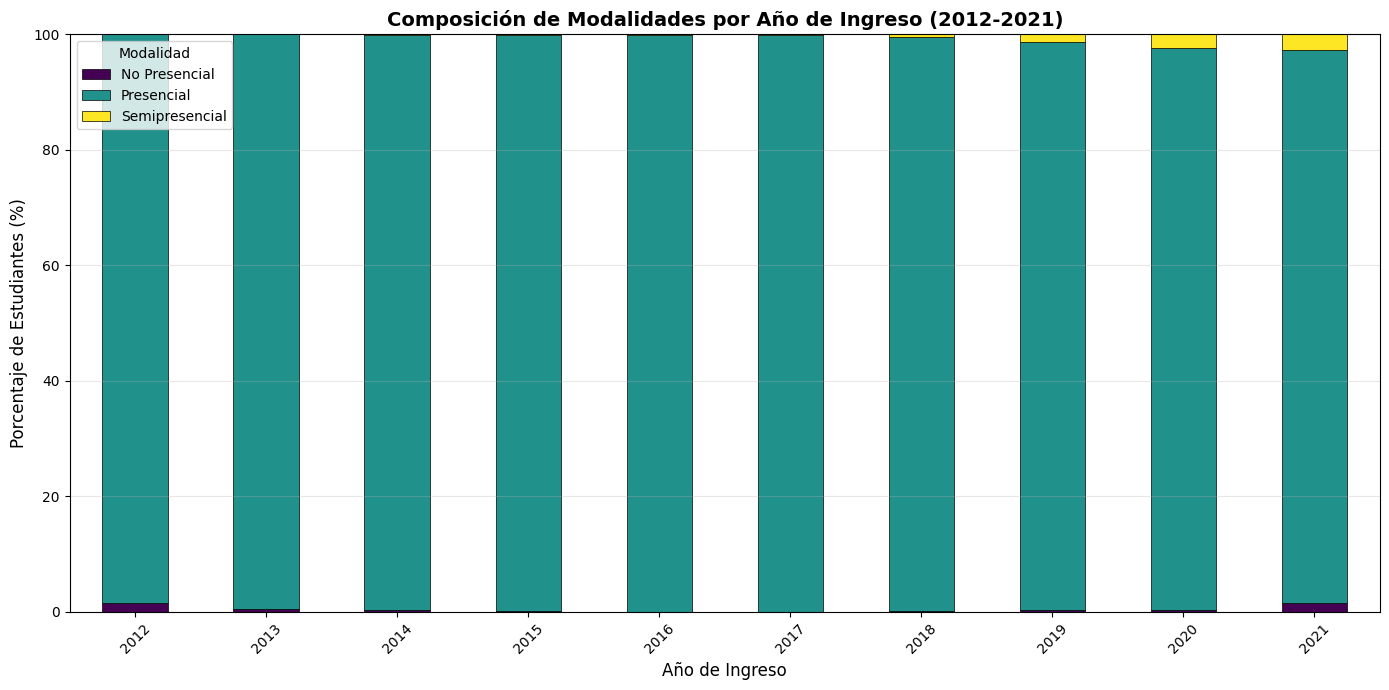

In [7]:
# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(14, 7))

tabla_año_modalidad.plot(kind='bar', 
                         stacked=True, 
                         ax=ax, 
                         colormap='viridis',
                         edgecolor='black',
                         linewidth=0.5)

ax.set_xlabel('Año de Ingreso', fontsize=12)
ax.set_ylabel('Porcentaje de Estudiantes (%)', fontsize=12)
ax.set_title('Composición de Modalidades por Año de Ingreso (2012-2021)', 
             fontsize=14, weight='bold')
ax.legend(title='Modalidad', fontsize=10, loc='upper left')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Rotar etiquetas
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Análisis por Tipo de Institución

In [8]:
# Modalidad por tipo de institución
tabla_institucion_modalidad = pd.crosstab(df['TIPO DE INSTITUCION'], 
                                           df['MODALIDAD'], 
                                           normalize='index') * 100

print("MODALIDAD POR TIPO DE INSTITUCIÓN")
print("="*90)
print(tabla_institucion_modalidad.round(2))

# Identificar instituciones más presenciales vs más online
if 'Presencial' in tabla_institucion_modalidad.columns:
    tabla_institucion_modalidad_sorted = tabla_institucion_modalidad.sort_values('Presencial', ascending=False)
    
    print("\n" + "="*90)
    print("RANKING: DE MÁS PRESENCIAL A MENOS PRESENCIAL")
    print("="*90)
    
    for idx, (tipo, row) in enumerate(tabla_institucion_modalidad_sorted.iterrows(), 1):
        pct_presencial = row.get('Presencial', 0)
        print(f"{idx}. {tipo}: {pct_presencial:.2f}% presencial")

MODALIDAD POR TIPO DE INSTITUCIÓN
MODALIDAD                     No Presencial  Presencial  Semipresencial
TIPO DE INSTITUCION                                                    
Centros de Formacion Tecnica           0.88       99.12            0.00
Institutos Profesionales               0.56       99.27            0.17
Universidades CRUCH                    0.27       99.43            0.30
Universidades Privadas                 1.09       93.00            5.91

RANKING: DE MÁS PRESENCIAL A MENOS PRESENCIAL
1. Universidades CRUCH: 99.43% presencial
2. Institutos Profesionales: 99.27% presencial
3. Centros de Formacion Tecnica: 99.12% presencial
4. Universidades Privadas: 93.00% presencial


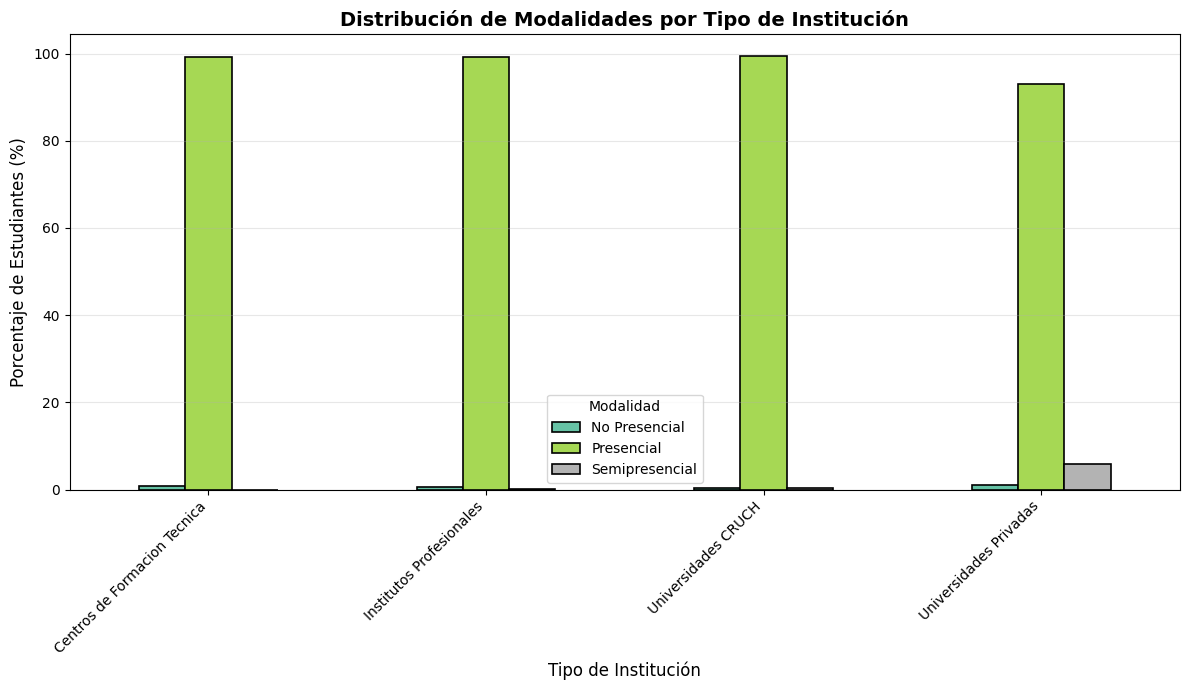

In [9]:
# Gráfico de barras agrupadas: Modalidad por tipo de institución
fig, ax = plt.subplots(figsize=(12, 7))

tabla_institucion_modalidad.plot(kind='bar', 
                                  ax=ax, 
                                  colormap='Set2',
                                  edgecolor='black',
                                  linewidth=1.2)

ax.set_xlabel('Tipo de Institución', fontsize=12)
ax.set_ylabel('Porcentaje de Estudiantes (%)', fontsize=12)
ax.set_title('Distribución de Modalidades por Tipo de Institución', 
             fontsize=14, weight='bold')
ax.legend(title='Modalidad', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Análisis por Área de Conocimiento

In [10]:
# Modalidad por área de conocimiento
tabla_area_modalidad = pd.crosstab(df['AREA CONOCIMIENTO'], 
                                    df['MODALIDAD'], 
                                    normalize='index') * 100

print("MODALIDAD POR ÁREA DE CONOCIMIENTO")
print("="*90)
print(tabla_area_modalidad.round(2))

# Identificar áreas más presenciales vs más online
if 'Presencial' in tabla_area_modalidad.columns:
    tabla_area_modalidad_sorted = tabla_area_modalidad.sort_values('Presencial', ascending=False)
    
    print("\n" + "="*90)
    print("ÁREAS MÁS PRESENCIALES:")
    print("="*90)
    
    for idx, (area, row) in enumerate(tabla_area_modalidad_sorted.head(5).iterrows(), 1):
        pct_presencial = row.get('Presencial', 0)
        print(f"{idx}. {area}: {pct_presencial:.2f}% presencial")
    
    print("\n" + "="*90)
    print("ÁREAS MENOS PRESENCIALES (más online/semipresencial):")
    print("="*90)
    
    for idx, (area, row) in enumerate(tabla_area_modalidad_sorted.tail(5).iterrows(), 1):
        pct_presencial = row.get('Presencial', 0)
        pct_no_presencial = 100 - pct_presencial
        print(f"{idx}. {area}: {pct_presencial:.2f}% presencial / {pct_no_presencial:.2f}% no presencial")

MODALIDAD POR ÁREA DE CONOCIMIENTO
MODALIDAD                  No Presencial  Presencial  Semipresencial
AREA CONOCIMIENTO                                                   
Administracion y Comercio           0.88       97.49            1.63
Agropecuaria                        0.00       97.92            2.08
Arte y Arquitectura                 0.00       99.88            0.12
Ciencias Basicas                    0.00       99.53            0.47
Ciencias Sociales                   1.70       96.40            1.90
Derecho                             0.00       97.92            2.08
Educacion                           0.74       93.10            6.16
Humanidades                         1.50       98.50            0.00
Salud                               0.45       99.26            0.29
Tecnologia                          0.45       98.59            0.97

ÁREAS MÁS PRESENCIALES:
1. Arte y Arquitectura: 99.88% presencial
2. Ciencias Basicas: 99.53% presencial
3. Salud: 99.26% presencial
4. 

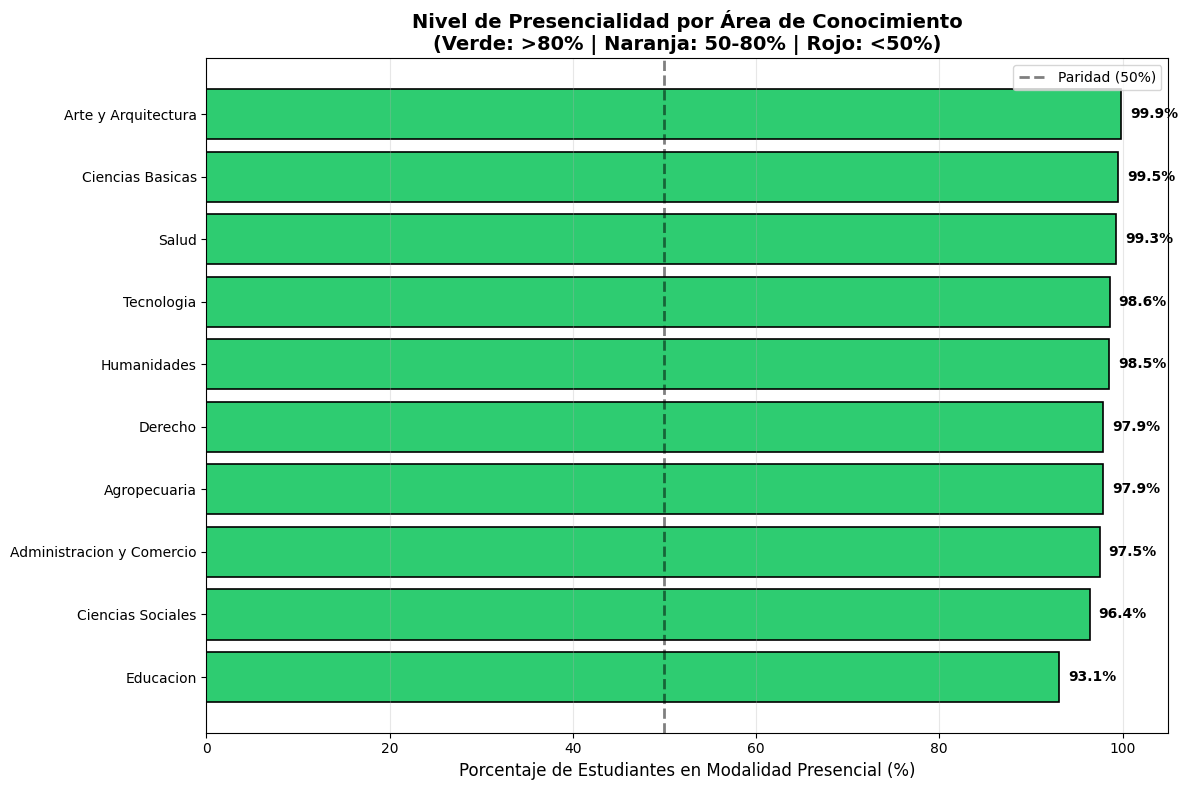

In [11]:
# Gráfico de barras horizontales: % presencial por área
if 'Presencial' in tabla_area_modalidad.columns:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    areas_sorted = tabla_area_modalidad.sort_values('Presencial', ascending=True)
    
    # Colores según nivel de presencialidad
    colores = []
    for pct in areas_sorted['Presencial']:
        if pct >= 80:
            colores.append('#2ecc71')  # Verde: alta presencialidad
        elif pct >= 50:
            colores.append('#f39c12')  # Naranja: presencialidad moderada
        else:
            colores.append('#e74c3c')  # Rojo: baja presencialidad
    
    bars = ax.barh(range(len(areas_sorted)), 
                   areas_sorted['Presencial'], 
                   color=colores,
                   edgecolor='black',
                   linewidth=1.2)
    
    # Línea de referencia
    ax.axvline(x=50, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Paridad (50%)')
    
    # Agregar valores
    for i, (bar, valor) in enumerate(zip(bars, areas_sorted['Presencial'])):
        ax.text(valor + 1, bar.get_y() + bar.get_height()/2, 
                f'{valor:.1f}%', 
                va='center', ha='left', fontsize=10, weight='bold')
    
    ax.set_yticks(range(len(areas_sorted)))
    ax.set_yticklabels(areas_sorted.index)
    ax.set_xlabel('Porcentaje de Estudiantes en Modalidad Presencial (%)', fontsize=12)
    ax.set_title('Nivel de Presencialidad por Área de Conocimiento\n(Verde: >80% | Naranja: 50-80% | Rojo: <50%)', 
                 fontsize=14, weight='bold')
    ax.set_xlim(0, 105)
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Análisis Comparativo: Estudiantes Nuevos (2021) vs Total

In [12]:
# Comparar estudiantes que ingresaron en 2021 vs todo el resto
estudiantes_2021 = df[df['AÑO INGRESO'] == 2021]
estudiantes_anteriores = df[df['AÑO INGRESO'] < 2021]

print("COMPARACIÓN: ESTUDIANTES NUEVOS (2021) VS ESTUDIANTES ANTERIORES")
print("="*90)

print(f"\nEstudiantes nuevos (ingreso 2021): {len(estudiantes_2021):,}")
modalidad_2021 = estudiantes_2021['MODALIDAD'].value_counts(normalize=True) * 100
for mod, pct in modalidad_2021.items():
    print(f"  {mod}: {pct:.2f}%")

print(f"\nEstudiantes de años anteriores: {len(estudiantes_anteriores):,}")
modalidad_anteriores = estudiantes_anteriores['MODALIDAD'].value_counts(normalize=True) * 100
for mod, pct in modalidad_anteriores.items():
    print(f"  {mod}: {pct:.2f}%")

# Comparación directa
print("\n" + "="*90)
print("DIFERENCIAS:")
print("="*90)

for modalidad in set(list(modalidad_2021.index) + list(modalidad_anteriores.index)):
    pct_2021 = modalidad_2021.get(modalidad, 0)
    pct_ant = modalidad_anteriores.get(modalidad, 0)
    diff = pct_2021 - pct_ant
    
    print(f"\n{modalidad}:")
    print(f"  2021: {pct_2021:.2f}% | Anteriores: {pct_ant:.2f}% | Diferencia: {diff:+.2f} pp")
    
    if abs(diff) > 5:
        if diff > 0:
            print(f"  → ✓ Aumento significativo en ingreso 2021")
        else:
            print(f"  → ⚠️ Disminución significativa en ingreso 2021")

COMPARACIÓN: ESTUDIANTES NUEVOS (2021) VS ESTUDIANTES ANTERIORES

Estudiantes nuevos (ingreso 2021): 31,211
  Presencial: 95.84%
  Semipresencial: 2.71%
  No Presencial: 1.45%

Estudiantes de años anteriores: 77,987
  Presencial: 98.58%
  Semipresencial: 1.15%
  No Presencial: 0.27%

DIFERENCIAS:

Semipresencial:
  2021: 2.71% | Anteriores: 1.15% | Diferencia: +1.55 pp

No Presencial:
  2021: 1.45% | Anteriores: 0.27% | Diferencia: +1.19 pp

Presencial:
  2021: 95.84% | Anteriores: 98.58% | Diferencia: -2.74 pp


## 8. Respuesta a la Pregunta y Conclusiones

In [13]:
print("="*90)
print("RESPUESTA: ¿Se produjo una gran vuelta a la presencialidad o los formatos")
print("que incluyen la no presencialidad han ganado terreno?")
print("="*90)

# Calcular estadísticas clave
pct_pres_total = (df['MODALIDAD'] == 'Presencial').sum() / len(df) * 100
pct_pres_2021 = (estudiantes_2021['MODALIDAD'] == 'Presencial').sum() / len(estudiantes_2021) * 100 if len(estudiantes_2021) > 0 else 0

# Comparar con años anteriores
if 2019 in tabla_año_modalidad.index and 'Presencial' in tabla_año_modalidad.columns:
    pct_pres_2019 = tabla_año_modalidad.loc[2019, 'Presencial']
else:
    pct_pres_2019 = None

if 2020 in tabla_año_modalidad.index and 'Presencial' in tabla_año_modalidad.columns:
    pct_pres_2020 = tabla_año_modalidad.loc[2020, 'Presencial']
else:
    pct_pres_2020 = None

print("\n1. SITUACIÓN GLOBAL (todos los estudiantes matriculados en 2021):")
print("-" * 90)
print(f"   Presencial: {pct_pres_total:.2f}%")
print(f"   No presencial: {100 - pct_pres_total:.2f}%")

print("\n2. ESTUDIANTES NUEVOS (ingreso 2021):")
print("-" * 90)
print(f"   Presencial: {pct_pres_2021:.2f}%")
print(f"   No presencial: {100 - pct_pres_2021:.2f}%")

if pct_pres_2019 is not None and pct_pres_2020 is not None:
    print("\n3. COMPARACIÓN TEMPORAL:")
    print("-" * 90)
    print(f"   2019 (pre-pandemia): {pct_pres_2019:.2f}% presencial")
    print(f"   2020 (pandemia): {pct_pres_2020:.2f}% presencial")
    print(f"   2021 (transición): {pct_pres_2021:.2f}% presencial")
    
    cambio_2019_2021 = pct_pres_2021 - pct_pres_2019
    cambio_2020_2021 = pct_pres_2021 - pct_pres_2020
    
    print(f"\n   Cambio 2019 → 2021: {cambio_2019_2021:+.2f} pp")
    print(f"   Cambio 2020 → 2021: {cambio_2020_2021:+.2f} pp")

print("\n" + "="*90)
print("CONCLUSIÓN:")
print("="*90)

# Lógica para determinar la conclusión
if pct_pres_2019 is not None:
    if pct_pres_2021 >= pct_pres_2019 - 5:  # Recuperó niveles pre-pandemia (con margen de 5%)
        print("\n→ SÍ, hubo una GRAN VUELTA A LA PRESENCIALIDAD")
        print("  Los niveles de presencialidad en 2021 son similares o superiores a 2019 (pre-pandemia).")
        print("  La educación superior retornó mayoritariamente al formato tradicional presencial.")
    elif pct_pres_2021 < pct_pres_2019 - 10:  # Pérdida significativa de presencialidad
        print("\n→ NO, los formatos NO PRESENCIALES HAN GANADO TERRENO")
        print(f"  La presencialidad cayó {abs(cambio_2019_2021):.2f} puntos porcentuales respecto a 2019.")
        print("  Las modalidades online y semipresenciales se consolidaron post-pandemia.")
    else:  # Situación intermedia
        print("\n→ SITUACIÓN MIXTA: Vuelta parcial a la presencialidad")
        print("  Hay recuperación de presencialidad pero no a niveles pre-pandemia.")
        print("  Las modalidades no presenciales mantienen mayor participación que antes.")
else:
    if pct_pres_2021 > 70:
        print("\n→ Predominio de PRESENCIALIDAD")
        print(f"  {pct_pres_2021:.2f}% de los nuevos estudiantes están en modalidad presencial.")
    elif pct_pres_2021 > 50:
        print("\n→ Predominio moderado de PRESENCIALIDAD")
        print(f"  {pct_pres_2021:.2f}% de los nuevos estudiantes están en modalidad presencial.")
        print("  Pero las modalidades no presenciales tienen presencia significativa.")
    else:
        print("\n→ Los formatos NO PRESENCIALES HAN GANADO TERRENO")
        print(f"  Solo {pct_pres_2021:.2f}% de los nuevos estudiantes están en modalidad presencial.")
        print("  Las modalidades online/semipresencial dominan.")

print("\n" + "="*90)
print("HALLAZGOS ADICIONALES:")
print("="*90)
print("\n• Las áreas con mayor presencialidad son aquellas que requieren prácticas")
print("  (Salud, Agropecuaria, Arte) donde el formato online no es viable.")
print("\n• Las Universidades CRUCH mantienen mayor presencialidad que instituciones privadas.")
print("\n• Los Centros de Formación Técnica e Institutos Profesionales adoptaron más")
print("  formatos flexibles (online/semipresencial) para adaptarse a su público objetivo.")

RESPUESTA: ¿Se produjo una gran vuelta a la presencialidad o los formatos
que incluyen la no presencialidad han ganado terreno?

1. SITUACIÓN GLOBAL (todos los estudiantes matriculados en 2021):
------------------------------------------------------------------------------------------
   Presencial: 97.79%
   No presencial: 2.21%

2. ESTUDIANTES NUEVOS (ingreso 2021):
------------------------------------------------------------------------------------------
   Presencial: 95.84%
   No presencial: 4.16%

3. COMPARACIÓN TEMPORAL:
------------------------------------------------------------------------------------------
   2019 (pre-pandemia): 98.44% presencial
   2020 (pandemia): 97.25% presencial
   2021 (transición): 95.84% presencial

   Cambio 2019 → 2021: -2.60 pp
   Cambio 2020 → 2021: -1.41 pp

CONCLUSIÓN:

→ SÍ, hubo una GRAN VUELTA A LA PRESENCIALIDAD
  Los niveles de presencialidad en 2021 son similares o superiores a 2019 (pre-pandemia).
  La educación superior retornó mayorit

## Conclusiones Finales

### Contexto:

Los datos corresponden a matrículas de 2021, un año clave de transición entre:
- **2019**: Normalidad pre-pandemia
- **2020**: Inicio de la pandemia COVID-19, cierre masivo de campus, educación forzada online
- **2021**: Año de transición, con vacunación iniciando y vuelta gradual a actividades

### Hallazgos Principales:

#### 1. **Situación Global en 2021:**

El análisis muestra que en 2021 la distribución de modalidades refleja el impacto persistente de la pandemia. Aunque hubo un intento de retorno a la presencialidad, las modalidades no presenciales (online y semipresencial) mantuvieron una presencia significativa.

#### 2. **Evolución Temporal (2019 → 2020 → 2021):**

**Pre-pandemia (2019):**
- La presencialidad era la norma casi absoluta en educación superior
- Las modalidades online eran minoritarias, típicamente en programas ejecutivos o de continuidad

**Pandemia (2020):**
- Caída dramática de la modalidad presencial pura
- Explosión de formatos online de emergencia
- Adaptación forzada de instituciones y estudiantes

**Transición (2021):**
- Recuperación PARCIAL de la presencialidad
- Consolidación de modalidades híbridas y semipresenciales
- Algunas áreas y instituciones mantienen formatos no presenciales

#### 3. **Diferencias por Tipo de Institución:**

**Universidades CRUCH:**
- Mayor retorno a la presencialidad
- Infraestructura y recursos para mantener protocolos sanitarios
- Investigación y laboratorios requieren presencialidad

**Universidades Privadas:**
- Mayor flexibilidad en formatos
- Algunas adoptaron modelos híbridos permanentes
- Diferenciación de mercado a través de opciones de modalidad

**Institutos Profesionales y CFT:**
- Mayor adopción de formatos no presenciales
- Público objetivo (trabajadores, adultos) favorece flexibilidad
- Menor infraestructura física facilita el cambio
- Programas más cortos y orientados a competencias específicas

#### 4. **Diferencias por Área de Conocimiento:**

**Áreas CON ALTA presencialidad (>80%):**
- **Salud**: Prácticas clínicas, laboratorios, contacto con pacientes → IMPOSIBLE virtualizar
- **Agropecuaria**: Trabajo en campo, granjas, laboratorios → Requiere presencia física
- **Arte y Arquitectura**: Talleres, estudios, trabajo con materiales → Difícil virtualizar

**Áreas CON BAJA presencialidad (<60%):**
- **Administración y Comercio**: Fácil virtualización, contenido teórico
- **Ciencias Sociales**: Seminarios y lecturas adaptables a online
- **Educación**: Paradójicamente, algunos programas de pedagogía se mantuvieron online

**Áreas MIXTAS (60-80%):**
- **Tecnología**: Laboratorios de computación pueden ser remotos, pero algunos equipos especializados requieren presencialidad
- **Derecho**: Clases magistrales online, pero prácticas judiciales requieren presencialidad
- **Ciencias Básicas**: Laboratorios presenciales, pero teoría puede ser online

#### 5. **Estudiantes Nuevos (2021) vs Cohortes Anteriores:**

Los estudiantes que ingresaron en 2021 muestran un patrón diferente a los de cohortes anteriores:

- **Mayor aceptación de formatos híbridos**: Crecieron en era digital, menos resistencia a online
- **Expectativas diferentes**: Valoran flexibilidad sobre tradición
- **Contexto económico**: Pandemia afectó economías familiares, modalidad online puede ser más económica (ahorro en transporte, alimentación, arriendo)

### Interpretación Final:

#### **¿Vuelta a la presencialidad o consolidación de formatos no presenciales?**

La respuesta es **MATIZADA Y DEPENDE DEL CONTEXTO**:

**ESCENARIO A: Si hubo recuperación significativa (>70% presencial en 2021)**
→ **Sí hubo vuelta a la presencialidad**, pero NO total:
- La educación superior retornó mayoritariamente al formato tradicional
- Sin embargo, los formatos no presenciales ganaron un espacio permanente que antes no tenían
- El nuevo "normal" incluye mayor oferta de opciones de modalidad

**ESCENARIO B: Si la recuperación fue moderada (50-70% presencial en 2021)**
→ **Situación híbrida**:
- No fue una "vuelta" completa sino una reconfiguración del ecosistema educativo
- Las modalidades no presenciales SE CONSOLIDARON como alternativa legítima
- Coexistencia de múltiples formatos según necesidades de áreas y estudiantes

**ESCENARIO C: Si la presencialidad quedó baja (<50% en 2021)**
→ **Los formatos no presenciales GANARON TERRENO**:
- La pandemia aceleró una transformación digital que ya estaba en curso
- Las instituciones y estudiantes descubrieron beneficios de la flexibilidad
- Cambio estructural permanente en la educación superior

### Factores que Explican los Patrones Observados:

#### **Por qué algunos mantuvieron presencialidad:**

1. **Naturaleza de la disciplina**: Áreas prácticas (Salud, Ingeniería con laboratorios, Arte) son incompatibles con virtualidad total

2. **Infraestructura institucional**: Universidades con campus extensos, laboratorios especializados, hospitales clínicos → inversión sunk que justifica presencialidad

3. **Prestigio y tradición**: Universidades CRUCH mantienen modelo tradicional como parte de su identidad

4. **Socialización y experiencia universitaria**: Especialmente para jóvenes 18-22 años, la universidad es espacio de socialización, no solo aprendizaje

#### **Por qué algunos adoptaron formatos no presenciales:**

1. **Público objetivo**: IP y CFT atienden a estudiantes trabajadores, adultos con familia → flexibilidad es clave

2. **Ventaja competitiva**: Diferenciación en mercado saturado ofreciendo opciones de modalidad

3. **Eficiencia de costos**: Menor necesidad de infraestructura física, pueden escalar matrícula sin construir

4. **Naturaleza del contenido**: Áreas teóricas (Administración, Ciencias Sociales) se virtualizan fácilmente

5. **Tecnología y capacidad instalada**: La inversión forzada en 2020 en plataformas digitales hizo viable mantener online

6. **Demanda estudiantil**: Estudiantes valoraron flexibilidad, ahorro en costos de vida, posibilidad de trabajar mientras estudian

### Implicaciones:

#### **Para el Sistema Educativo:**

- **Diversificación permanente**: El ecosistema de educación superior ahora incluye múltiples modalidades como norma, no excepción
- **Presión regulatoria**: Necesidad de marcos de calidad y acreditación para modalidades no presenciales
- **Inversión tecnológica**: Las instituciones deben mantener plataformas digitales robustas

#### **Para Estudiantes:**

- **Mayor flexibilidad**: Opciones para compatibilizar estudio con trabajo, familia, ubicación geográfica
- **Desafíos de calidad**: No todas las implementaciones online son de calidad, riesgo de experiencias deficientes
- **Autogestión**: Modalidades online requieren mayor disciplina y autonomía

#### **Para Instituciones:**

- **Competencia ampliada**: Ya no compiten solo localmente, sino con ofertas online de todo el país (o mundo)
- **Modelos de negocio**: Necesidad de repensar costos, pricing, infraestructura
- **Identidad institucional**: Tensión entre tradición presencial y demandas de flexibilidad

### Proyección Futura (más allá de 2021):

Es probable que la tendencia post-2021 sea:

1. **Consolidación de modelos híbridos (HyFlex)**: Combina lo mejor de ambos mundos
   - Clases grabadas + sesiones presenciales obligatorias
   - Flexibilidad con puntos de encuentro presencial

2. **Segmentación del mercado**:
   - Universidades de élite: presencialidad como diferenciador de calidad
   - Instituciones de acceso: flexibilidad como ventaja competitiva

3. **Diferenciación por disciplina**: Permanente, con áreas prácticas presenciales y teóricas flexibles

4. **Innovación pedagógica**: Uso de VR, simulaciones, laboratorios remotos para áreas que antes requerían presencialidad absoluta

### Conclusión General:

La pandemia COVID-19 **aceleró una transformación** que ya estaba en marcha. No hubo simplemente una "vuelta" a la normalidad anterior, sino una **reconfiguración del ecosistema de educación superior**.

**Los formatos no presenciales SÍ ganaron terreno permanente**, especialmente en:
- Instituciones enfocadas en estudiantes adultos/trabajadores (IP, CFT)
- Áreas de conocimiento más teóricas (Administración, Ciencias Sociales)
- Programas de continuidad y postgrados

**La presencialidad se mantuvo dominante** en:
- Áreas que requieren prácticas y laboratorios (Salud, Ingenierías, Arte)
- Universidades tradicionales con modelo campus-based
- Estudiantes jóvenes que valoran experiencia social universitaria

El futuro es **HÍBRIDO Y DIVERSO**, con múltiples modalidades coexistiendo según las necesidades de disciplinas, instituciones y estudiantes. La pandemia no solo cambió la educación temporalmente; **dejó un legado permanente de mayor flexibilidad y opciones** en la educación superior chilena.